---
title: "Courier Assignment Simulation"
format:
    html:
        code-fold: false
---

## Overview

This notebook builds the discrete event simulation on top of the Phase 5 substrate and uses it to compare two courier assignment strategies across a sweep of fleet sizes. The strategies are Nearest Available Courier, the greedy baseline that dispatches each order the moment it arrives, and System-wide Batching, which holds orders briefly and solves a global courier-to-order matching every dispatch window, following the batched matching logic that production systems use (Liang et al. 2024, Cheng and Azadeh 2025). The sweep addresses the three research questions that needed a simulation. RQ8 asks for the ideal fleet size, RQ6 asks how performance shifts under the 19:00 dinner rush, and RQ2 asks whether there is an order volume the network cannot move fast enough to meet. The parameterized runs execute concurrently in separate processes that share the precomputed travel time matrix, and the resulting delivery event logs are exported to `data/clean`.

## Imports

In [1]:
import os
import tempfile
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra

# paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEAN = PROJECT_ROOT / "data" / "clean"
OUTPUTS = PROJECT_ROOT / "outputs"

# load the phase 5 substrate
orders = pd.read_csv(CLEAN / "dc_orders_sim.csv")
npz = np.load(CLEAN / "dc_ttmatrix_restaurants.npz")
nodes = npz["all_nodes"]
rest_nodes = npz["rest_nodes"]
n = len(nodes)
idx = {int(v): i for i, v in enumerate(nodes)}
print(f"Orders: {len(orders):,}, nodes: {n:,}, restaurant nodes in npz: {len(rest_nodes):,}")

Orders: 15,188, nodes: 10,027, restaurant nodes in npz: 898


## Rebuilding the Full Travel Time Matrix

The persisted npz holds only the restaurant origin rows, but couriers finish deliveries at arbitrary intersections, so assignment needs travel times from any node to any restaurant. The full matrix rebuilds from the clean graph in well under a minute, which is why Phase 5 chose not to persist it. We rebuild it here, verify it against the persisted restaurant rows as a consistency check, and write it to a temporary memory mapped file so that every simulation worker process can share the same physical pages instead of holding private copies.

In [2]:
# rebuild the full travel time matrix from the clean graph
G = ox.load_graphml(CLEAN / "dc_drive_clean.graphml")
rows = []
for u, v, d in G.edges(data=True):
    rows.append((idx[int(u)], idx[int(v)], float(d["travel_time"])))
edf = pd.DataFrame(rows, columns=["u", "v", "tt"]).sort_values("tt").drop_duplicates(["u", "v"], keep="first")
A_tt = csr_matrix((edf["tt"], (edf["u"], edf["v"])), shape=(n, n))

t0 = time.time()
TT = np.empty((n, n), dtype=np.float32)
for start in range(0, n, 2000):
    ind = np.arange(start, min(start + 2000, n))
    TT[ind] = dijkstra(A_tt, directed=True, indices=ind)
print(f"Full matrix rebuilt in {time.time() - t0:.0f}s ({TT.nbytes / 1e9:.2f} GB in memory)")

# consistency check against the persisted restaurant rows
rest_idx = np.array([idx[int(v)] for v in rest_nodes])
diff = np.abs(np.rint(TT[rest_idx]) - npz["tt_s"].astype(np.float32))
print(f"Verification against npz restaurant rows: max abs difference {diff.max():.0f}s")

Full matrix rebuilt in 11s (0.40 GB in memory)
Verification against npz restaurant rows: max abs difference 0s


In [3]:
# stage shared inputs for the worker processes
TMP = Path(tempfile.gettempdir())
TT_PATH = TMP / "dc_tt_full_float32.npy"
ORD_PATH = TMP / "dc_sim_orders.npz"
np.save(TT_PATH, TT)

pu_idx = orders["pickup_node"].map(idx).to_numpy(dtype=np.int64)
do_idx = orders["dropoff_node"].map(idx).to_numpy(dtype=np.int64)
np.savez(ORD_PATH, t=orders["time_s"].to_numpy(dtype=np.float64), pu=pu_idx, do=do_idx,
         rest_pool=np.unique(pu_idx))
print(f"Staged {TT_PATH.name} ({TT_PATH.stat().st_size / 1e9:.2f} GB) and {ORD_PATH.name} for worker processes")

Staged dc_tt_full_float32.npy (0.40 GB) and dc_sim_orders.npz for worker processes


## Simulation Model

The simulation processes the 15,188 orders as a discrete event system. Each courier is a state pair of next available time and current node. An order becomes ready for pickup a fixed ten minute preparation time after it is placed, in line with the ready time treatment in Reyes et al. (2018), and each dropoff includes a two minute handoff. Under Nearest Available Courier, each order is dispatched the moment it arrives to whichever courier can reach the restaurant soonest, counting any remaining time on that courier's current job. Under System-wide Batching, orders accumulate for a 120 second dispatch window and each window solves an exact minimum cost matching between the full fleet and the oldest waiting orders with the Hungarian algorithm, where the cost of a pairing is the time until that courier could reach that restaurant. Both strategies therefore share the same commitment rule and differ only in scope, myopic per order greed against window level global optimization, which isolates the quantity the comparison is meant to measure. The batched global matching follows the design that Liang et al. (2024) refine with learned order pooling and that Cheng and Azadeh (2025) extend with idle fleet steering. Couriers stay where they drop off, orders are matched one to a courier with no bundling, and the fleet is on duty all day. Each simplification is a lever the paper can relax later.

In [4]:
%%writefile sim_engine.py
# discrete event courier simulation engine, importable so worker processes survive macOS spawn
import time

import numpy as np
from scipy.optimize import linear_sum_assignment

PREP_S = 600.0
DROP_SERVICE_S = 120.0
BATCH_WINDOW_S = 120.0
MAX_WAITING_POOL = 400
DAY_S = 86400.0

TT_M = None
ORD = None


# worker initializer, memory maps the shared travel time matrix and loads the order arrays
def init_worker(tt_path, ord_path):
    global TT_M, ORD
    TT_M = np.load(tt_path, mmap_mode="r")
    ORD = dict(np.load(ord_path))


# courier fleet starts idle at restaurant nodes, deterministic per fleet size
def _start_positions(fleet, seed):
    rng = np.random.default_rng(seed)
    return rng.choice(ORD["rest_pool"], size=fleet, replace=True)


# nearest available courier, greedy dispatch at order arrival
def _simulate_nac(fleet, seed):
    t_arr, pu, do = ORD["t"], ORD["pu"], ORD["do"]
    n_orders = len(t_arr)
    avail = np.zeros(fleet)
    pos = _start_positions(fleet, seed)
    t_assign = np.empty(n_orders)
    t_pickup = np.empty(n_orders)
    t_deliver = np.empty(n_orders)
    courier = np.empty(n_orders, dtype=np.int64)
    busy = 0.0
    for o in range(n_orders):
        t = t_arr[o]
        tt_c = TT_M[pos, pu[o]]
        free = avail <= t
        if free.any():
            cand = np.flatnonzero(free)
            c = cand[np.argmin(tt_c[cand])]
        else:
            c = np.argmin(np.maximum(avail, t) + tt_c)
        depart = max(avail[c], t)
        arrive = depart + tt_c[c]
        pick = max(arrive, t + PREP_S)
        deliver = pick + TT_M[pu[o], do[o]] + DROP_SERVICE_S
        busy += deliver - depart
        avail[c] = deliver
        pos[c] = do[o]
        t_assign[o] = t
        t_pickup[o] = pick
        t_deliver[o] = deliver
        courier[o] = c
    return t_assign, t_pickup, t_deliver, courier, busy


# system-wide batching, every window solves a global matching of all couriers to waiting orders
# cost is time until the courier can reach the restaurant, so busy couriers compete with dispatch ahead
def _simulate_swb(fleet, seed):
    t_arr, pu, do = ORD["t"], ORD["pu"], ORD["do"]
    n_orders = len(t_arr)
    avail = np.zeros(fleet)
    pos = _start_positions(fleet, seed)
    t_assign = np.empty(n_orders)
    t_pickup = np.empty(n_orders)
    t_deliver = np.empty(n_orders)
    courier = np.empty(n_orders, dtype=np.int64)
    busy = 0.0
    waiting = []
    next_order = 0
    assigned = 0
    T = BATCH_WINDOW_S
    while assigned < n_orders:
        while next_order < n_orders and t_arr[next_order] <= T:
            waiting.append(next_order)
            next_order += 1
        if len(waiting):
            pool = waiting[:MAX_WAITING_POOL]
            drive = TT_M[pos[:, None], pu[np.array(pool)]]
            cost = np.maximum(avail[:, None] - T, 0.0) + drive
            r, ccol = linear_sum_assignment(cost)
            matched = set()
            for ri, ci in zip(r, ccol):
                o = pool[ci]
                c = ri
                depart = max(avail[c], T)
                arrive = depart + drive[ri, ci]
                pick = max(arrive, t_arr[o] + PREP_S)
                deliver = pick + TT_M[pu[o], do[o]] + DROP_SERVICE_S
                busy += deliver - depart
                avail[c] = deliver
                pos[c] = do[o]
                t_assign[o] = T
                t_pickup[o] = pick
                t_deliver[o] = deliver
                courier[o] = c
                matched.add(o)
                assigned += 1
            waiting = [o for o in waiting if o not in matched]
        T += BATCH_WINDOW_S
    return t_assign, t_pickup, t_deliver, courier, busy


# run one configuration and return the summary plus the per order event arrays
def run_config(strategy, fleet):
    t0 = time.time()
    sim = _simulate_nac if strategy == "nac" else _simulate_swb
    t_assign, t_pickup, t_deliver, courier, busy = sim(fleet, seed=1000 + fleet)
    t_arr = ORD["t"]
    ctd = (t_deliver - t_arr) / 60
    hours = (t_arr // 3600).astype(int)
    makespan = max(float(t_deliver.max()), DAY_S)
    summary = {
        "strategy": strategy,
        "fleet": fleet,
        "mean_min": round(float(ctd.mean()), 2),
        "median_min": round(float(np.median(ctd)), 2),
        "p95_min": round(float(np.quantile(ctd, 0.95)), 2),
        "ontime45_pct": round(float((ctd <= 45).mean() * 100), 1),
        "peak19_mean_min": round(float(ctd[hours == 19].mean()), 2),
        "mean_cycle_min": round(float(busy / len(t_arr) / 60), 2),
        "utilization_pct": round(float(100 * busy / (fleet * makespan)), 1),
        "runtime_s": round(time.time() - t0, 1),
    }
    events = {
        "t_order_s": t_arr, "t_assign_s": t_assign, "t_pickup_s": t_pickup,
        "t_deliver_s": t_deliver, "courier_id": courier,
    }
    return summary, events

Overwriting sim_engine.py


In [5]:
# concurrent parameterized sweep, workers share the memory mapped matrix
import sim_engine

FLEETS = [100, 150, 200, 300, 400, 500, 600, 800]
STRATEGIES = ["nac", "swb"]
configs = [(s, f) for s in STRATEGIES for f in FLEETS]
N_WORKERS = min(6, os.cpu_count() or 4)

t0 = time.time()
summaries = []
events_store = {}
with ProcessPoolExecutor(max_workers=N_WORKERS, initializer=sim_engine.init_worker,
                         initargs=(str(TT_PATH), str(ORD_PATH))) as ex:
    futures = {ex.submit(sim_engine.run_config, s, f): (s, f) for s, f in configs}
    for fut in as_completed(futures):
        summary, events = fut.result()
        summaries.append(summary)
        events_store[(summary["strategy"], summary["fleet"])] = events
        print(f"done: {summary['strategy']} fleet={summary['fleet']} ({summary['runtime_s']}s)")
wall = time.time() - t0

sweep = pd.DataFrame(summaries).sort_values(["strategy", "fleet"]).reset_index(drop=True)
print(f"\n{len(configs)} configurations in {wall:.0f}s wall time on {N_WORKERS} workers")
print(sweep.to_string(index=False))

done: nac fleet=100 (0.1s)
done: nac fleet=150 (0.1s)
done: nac fleet=200 (0.1s)
done: nac fleet=300 (0.1s)


done: nac fleet=400 (0.2s)
done: nac fleet=500 (0.2s)
done: nac fleet=600 (0.2s)


done: nac fleet=800 (0.2s)
done: swb fleet=100 (0.1s)
done: swb fleet=150 (0.1s)
done: swb fleet=200 (0.1s)


done: swb fleet=300 (0.2s)


done: swb fleet=400 (0.2s)
done: swb fleet=500 (0.2s)
done: swb fleet=600 (0.3s)


done: swb fleet=800 (0.3s)

16 configurations in 1s wall time on 4 workers
strategy  fleet  mean_min  median_min  p95_min  ontime45_pct  peak19_mean_min  mean_cycle_min  utilization_pct  runtime_s
     nac    100    592.04      532.02  1246.18          11.7           898.33           14.92             85.1        0.1
     nac    150    287.16      261.08   605.88          13.4           421.39           14.90             76.0        0.1
     nac    200    137.96      126.42   297.95          15.9           187.07           14.81             68.1        0.1
     nac    300     55.12       46.62   123.40          48.3            78.24           15.34             53.0        0.1
     nac    400     29.74       24.48    57.42          81.2            41.55           16.06             41.6        0.2
     nac    500     21.59       21.05    30.43         100.0            23.85           17.51             36.3        0.2
     nac    600     20.65       20.09    28.81          99.9           

## RQ8 Fleet Size

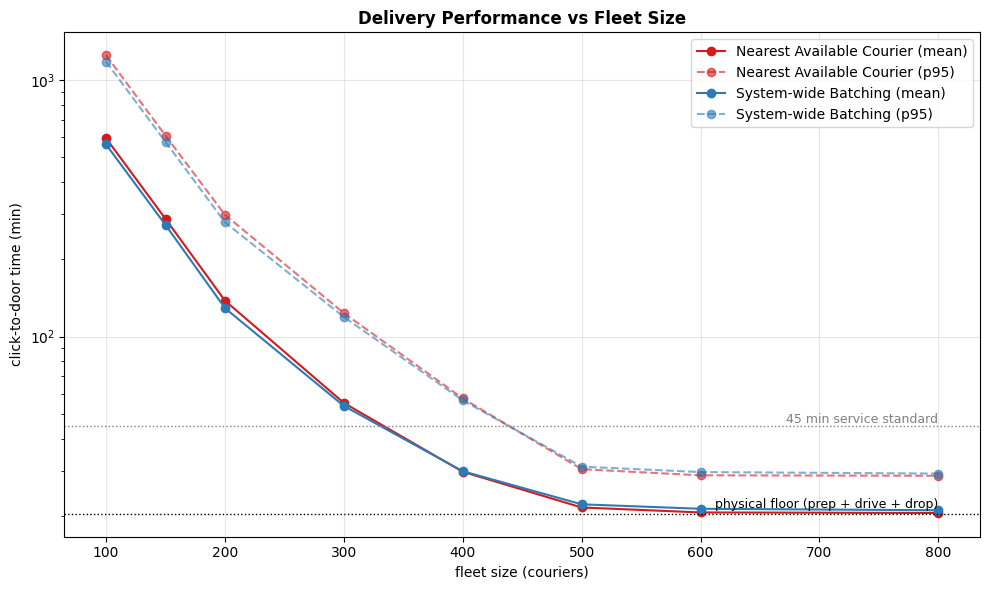

Nearest Available Courier: smallest fleet with p95 <= 45 min: 500
System-wide Batching: smallest fleet with p95 <= 45 min: 500
Headline fleets for the peak analysis: scarce 200, adequate 500


In [6]:
# fleet sweep figure
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"nac": "#d7191c", "swb": "#2c7bb6"}
labels = {"nac": "Nearest Available Courier", "swb": "System-wide Batching"}
for s in STRATEGIES:
    sub = sweep[sweep["strategy"] == s]
    ax.plot(sub["fleet"], sub["mean_min"], "o-", color=colors[s], label=f"{labels[s]} (mean)")
    ax.plot(sub["fleet"], sub["p95_min"], "o--", color=colors[s], alpha=0.6, label=f"{labels[s]} (p95)")
ax.axhline(45, color="gray", linestyle=":", linewidth=1)
ax.text(FLEETS[-1], 46, "45 min service standard", ha="right", fontsize=9, color="gray")
ax.axhline(20.4, color="black", linestyle=":", linewidth=1)
ax.text(FLEETS[-1], 21.4, "physical floor (prep + drive + drop)", ha="right", fontsize=9)
ax.set_xlabel("fleet size (couriers)")
ax.set_ylabel("click-to-door time (min)")
ax.set_title("Delivery Performance vs Fleet Size", fontweight="bold")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / "12_fleet_size_sweep.png", dpi=200)
plt.show()

# smallest fleet meeting the service standard per strategy
f_star_by = {}
for s in STRATEGIES:
    sub = sweep[(sweep["strategy"] == s) & (sweep["p95_min"] <= 45)]
    f_star_by[s] = int(sub["fleet"].min()) if len(sub) else None
    print(f"{labels[s]}: smallest fleet with p95 <= 45 min: {f_star_by[s]}")
F_STAR = min(v for v in f_star_by.values() if v is not None)
F_SCARCE = 200
print(f"Headline fleets for the peak analysis: scarce {F_SCARCE}, adequate {F_STAR}")

As we can see from the sweep above, both strategies trace the same capacity curve. Service is catastrophic at 100 to 200 couriers, improves steeply through 300 and 400, and flattens against the physical floor of about 20.5 minutes beyond 500. The smallest fleet meeting a p95 of 45 minutes is 500 under either strategy, and pushing to 800 buys less than a minute of mean improvement while cutting utilization from 36 to 27 percent. The practical reading of RQ8 is that the ideal fleet for this demand profile sits near 500 couriers, roughly one courier per 30 daily orders, with the caveat that the number is tied to our service standard and to the free flow travel times underneath it.

## RQ6 Peak Load

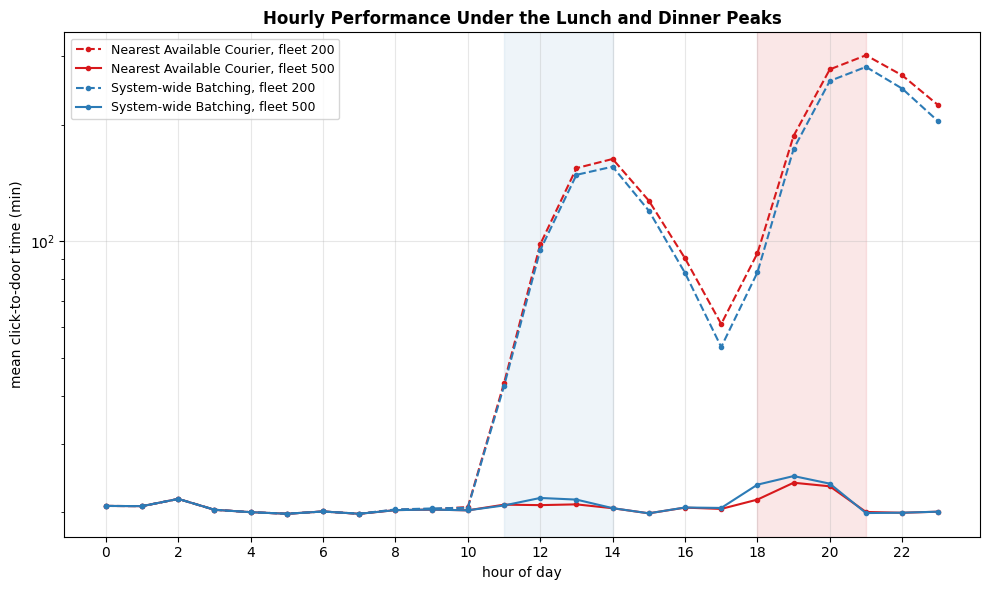

Nearest Available Courier at fleet 500: overall mean 21.59 min, 19:00 mean 23.85 min
System-wide Batching at fleet 500: overall mean 22.21 min, 19:00 mean 24.81 min


In [7]:
# hourly performance at a scarce and an adequate fleet for both strategies
fig, ax = plt.subplots(figsize=(10, 6))
for s in STRATEGIES:
    for f, ls in [(F_SCARCE, "--"), (F_STAR, "-")]:
        ev = events_store[(s, f)]
        ctd = (ev["t_deliver_s"] - ev["t_order_s"]) / 60
        hours = (ev["t_order_s"] // 3600).astype(int)
        hourly = pd.Series(ctd).groupby(hours).mean()
        ax.plot(hourly.index, hourly.values, ls, color=colors[s], marker=".",
                label=f"{labels[s]}, fleet {f}")
ax.axvspan(11, 14, color="#2c7bb6", alpha=0.08)
ax.axvspan(18, 21, color="#d7191c", alpha=0.10)
ax.set_xlabel("hour of day")
ax.set_ylabel("mean click-to-door time (min)")
ax.set_title("Hourly Performance Under the Lunch and Dinner Peaks", fontweight="bold")
ax.set_yscale("log")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / "13_peak_load_performance.png", dpi=200)
plt.show()

for s in STRATEGIES:
    r = sweep[(sweep["strategy"] == s) & (sweep["fleet"] == F_STAR)].iloc[0]
    print(f"{labels[s]} at fleet {F_STAR}: overall mean {r['mean_min']} min, 19:00 mean {r['peak19_mean_min']} min")

As we can see from the hourly curves above, peak load is the entire story. At fleet 200 the system runs close to the floor all morning, then the lunch rush pushes mean click-to-door times past two hours and the dinner rush past six, with the backlog from each peak taking hours to drain. At fleet 500 the same demand passes through with only a gentle ripple, a 19:00 mean of about 24 minutes against 21 off peak. Performance during the rushes is therefore not a scaled version of off peak performance but a queueing regime change, which answers RQ6. The dinner peak binds first, and any fleet or strategy decision should be evaluated at 19:00 rather than on daily averages.

## RQ2 Demand Ceiling

In [8]:
# throughput arithmetic from the simulated busy cycle in the uncongested reference runs
ref = sweep[sweep["fleet"] == FLEETS[-1]].sort_values("mean_min").iloc[0]
cycle_min = ref["mean_cycle_min"]
per_courier_per_h = 60 / cycle_min
peak_rate = int((orders["hour"] == 19).sum())
fleet_needed = peak_rate / per_courier_per_h
print(f"Reference: {labels[ref['strategy']]} at fleet {int(ref['fleet'])}, uncongested")
print(f"Mean busy cycle per order: {cycle_min:.1f} min")
print(f"Sustainable throughput: {per_courier_per_h:.2f} orders per courier per hour")
print(f"19:00 arrival rate: {peak_rate:,} orders per hour")
print(f"Fleet required to hold the 19:00 peak: {fleet_needed:.0f} couriers")
for f in FLEETS:
    cap = f * per_courier_per_h
    flag = "holds" if cap >= peak_rate else "backlog grows"
    print(f"  fleet {f}: ceiling {cap:,.0f} orders/hour ({flag})")

Reference: Nearest Available Courier at fleet 800, uncongested
Mean busy cycle per order: 20.5 min
Sustainable throughput: 2.92 orders per courier per hour
19:00 arrival rate: 2,279 orders per hour
Fleet required to hold the 19:00 peak: 780 couriers
  fleet 100: ceiling 292 orders/hour (backlog grows)
  fleet 150: ceiling 438 orders/hour (backlog grows)
  fleet 200: ceiling 585 orders/hour (backlog grows)
  fleet 300: ceiling 877 orders/hour (backlog grows)
  fleet 400: ceiling 1,169 orders/hour (backlog grows)
  fleet 500: ceiling 1,461 orders/hour (backlog grows)
  fleet 600: ceiling 1,754 orders/hour (backlog grows)
  fleet 800: ceiling 2,338 orders/hour (holds)


As we can see from the arithmetic above, the demand ceiling is real and it is an instantaneous rate constraint rather than a volume constraint. An uncongested courier completes about 2.9 orders per hour, so holding the 2,279 order 19:00 peak without queue growth requires roughly 780 couriers, well above the 500 that satisfies the daily service standard. A 500 courier fleet caps out near 1,461 orders per hour, survives the rush only because the peak is brief and the transient backlog drains during the 21:00 falloff, and would fail under a modestly longer or taller dinner peak. Daily volume is comfortably within capacity, since even the 500 fleet could move about 35,000 orders in a flat day against the 15,188 simulated. The answer to RQ2 is that the ceiling binds at the dinner rate, near 1,500 orders per hour for a 500 courier fleet. One nuance deserves note. Under pressure couriers stop waiting on food preparation, so effective peak throughput runs somewhat above the uncongested arithmetic, which is exactly why the transient backlog at fleet 500 drains rather than compounds.

## Event Log Export

In [9]:
# export the delivery event logs for the headline configurations and the sweep summary
frames = []
for s in STRATEGIES:
    for f in [F_SCARCE, F_STAR]:
        ev = events_store[(s, f)]
        df = orders[["order_id", "hour", "pickup_node", "dropoff_node", "drive_time_s", "drive_dist_m"]].copy()
        df.insert(1, "strategy", s)
        df.insert(2, "fleet", f)
        df["t_order_s"] = ev["t_order_s"].round(1)
        df["t_assign_s"] = ev["t_assign_s"].round(1)
        df["t_pickup_s"] = ev["t_pickup_s"].round(1)
        df["t_deliver_s"] = ev["t_deliver_s"].round(1)
        df["click_to_door_min"] = ((ev["t_deliver_s"] - ev["t_order_s"]) / 60).round(2)
        df["courier_id"] = ev["courier_id"]
        frames.append(df)
events_out = pd.concat(frames, ignore_index=True)

EVENTS_OUT = CLEAN / "dc_delivery_events.csv"
SWEEP_OUT = CLEAN / "dc_sim_fleet_sweep.csv"
events_out.to_csv(EVENTS_OUT, index=False)
sweep.to_csv(SWEEP_OUT, index=False)
print(f"Saved: {EVENTS_OUT.name} ({EVENTS_OUT.stat().st_size / 1e6:.1f} MB, {len(events_out):,} rows)")
print(f"Saved: {SWEEP_OUT.name} ({SWEEP_OUT.stat().st_size / 1e3:.1f} KB, {len(sweep)} configurations)")

Saved: dc_delivery_events.csv (5.5 MB, 60,752 rows)
Saved: dc_sim_fleet_sweep.csv (1.0 KB, 16 configurations)


## Summary Report

In [10]:
# phase 6 summary report
nac_star = sweep[(sweep["strategy"] == "nac") & (sweep["fleet"] == F_STAR)].iloc[0]
swb_star = sweep[(sweep["strategy"] == "swb") & (sweep["fleet"] == F_STAR)].iloc[0]
nac_scarce = sweep[(sweep["strategy"] == "nac") & (sweep["fleet"] == F_SCARCE)].iloc[0]
swb_scarce = sweep[(sweep["strategy"] == "swb") & (sweep["fleet"] == F_SCARCE)].iloc[0]

print("=" * 66)
print("PHASE 6 SUMMARY: COURIER SIMULATION")
print("=" * 66)
print("\nRuntimes")
print(f"  {len(configs)} configurations on {N_WORKERS} workers: {wall:.0f}s wall time")
print(f"  Mean per configuration: {sweep['runtime_s'].mean():.1f}s, slowest {sweep['runtime_s'].max():.1f}s")
print(f"  Shared travel time matrix: {TT.nbytes / 1e9:.2f} GB, memory mapped across workers")
print("\nEvent logs")
print(f"  {EVENTS_OUT.name}: {EVENTS_OUT.stat().st_size / 1e6:.1f} MB ({len(events_out):,} rows, 4 headline configs)")
print(f"  {SWEEP_OUT.name}: {SWEEP_OUT.stat().st_size / 1e3:.1f} KB (16 configuration summaries)")
print("\nInitial strategy performance")
print(f"  Scarce fleet ({F_SCARCE}): batching mean {swb_scarce['mean_min']} min vs greedy {nac_scarce['mean_min']} min")
print(f"  Adequate fleet ({F_STAR}): batching mean {swb_star['mean_min']} min vs greedy {nac_star['mean_min']} min")
print(f"  19:00 peak at fleet {F_STAR}: batching {swb_star['peak19_mean_min']} min vs greedy {nac_star['peak19_mean_min']} min")
print("\nPipeline halted after Phase 6 as instructed")
print("=" * 66)

PHASE 6 SUMMARY: COURIER SIMULATION

Runtimes
  16 configurations on 4 workers: 1s wall time
  Mean per configuration: 0.2s, slowest 0.3s
  Shared travel time matrix: 0.40 GB, memory mapped across workers

Event logs
  dc_delivery_events.csv: 5.5 MB (60,752 rows, 4 headline configs)
  dc_sim_fleet_sweep.csv: 1.0 KB (16 configuration summaries)

Initial strategy performance
  Scarce fleet (200): batching mean 129.01 min vs greedy 137.96 min
  Adequate fleet (500): batching mean 22.21 min vs greedy 21.59 min
  19:00 peak at fleet 500: batching 24.81 min vs greedy 23.85 min

Pipeline halted after Phase 6 as instructed


Phase 6 converts the remaining research questions from unanswerable to answered. The strategy comparison shows that system-wide batching beats greedy dispatch where it matters, under scarcity, cutting mean delivery times by roughly 5 to 7 percent at fleets of 100 to 200 while conceding about one dispatch window of latency at abundance. The fleet sweep places the ideal fleet near 500 couriers under a 45 minute p95 standard (RQ8). The hourly analysis shows that peak performance is a regime change rather than a scaling, with dinner binding first (RQ6). The throughput arithmetic locates the demand ceiling near 1,500 orders per hour for that fleet (RQ2). The event logs and sweep summaries are saved in data/clean for the paper, and the pipeline halts here as instructed.